<a href="https://colab.research.google.com/github/seigdev/artificial-intelligence/blob/main/assessments/assignment_one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip3 install Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.9 MB/s eta 0:00:00


In [47]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_hub as hub
import seaborn as sns
import tldextract
import re
import whois
import numpy as np
from datetime import datetime
from urllib.parse import urlparse
from Levenshtein import distance as levenshtein_distance
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from gensim.models import Word2Vec
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Masking, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.sequence import pad_sequences

## data collection

In [4]:
def fetch_crypto_datasets(url):
    # Make the request
    response = requests.get(url)
    if response.status_code == 200:
        # Return the JSON data
        return response.json()
    else:
        print(f"Failed to fetch data. Status code: {response.status_code}. Reason: {response.reason}")

        return []

In [5]:
datasets_raw = fetch_crypto_datasets("https://raw.githubusercontent.com/seigdev/artificial-intelligence/refs/heads/main/crypto_data.json")

In [6]:
datasets_df = pd.DataFrame(datasets_raw)

## eda

In [7]:
# view the first few rows
datasets_df.head()

,url,label,label_no
0,https://arbitrum-claim.net,scam,1
1,https://allocate-dym.network,scam,1
2,https://rionegro.com.ar,legit,0
3,https://net-layerzero.com,scam,1
4,https://leugss.top,scam,1


In [8]:
# basic info
print(datasets_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   url       100000 non-null  object
 1   label     100000 non-null  object
 2   label_no  100000 non-null  object
dtypes: object(3)
memory usage: 2.3+ MB
None


In [9]:
# count the number of scam and legitimate links
datasets_df["label"].value_counts()

label
scam     80000
legit    20000
Name: count, dtype: int64

In [10]:
# Summary statistics for numerical columns (if any)
print(datasets_df.describe())

                                 url   label label_no
count                         100000  100000   100000
unique                         99680       2        2
top     https://app.uniswap.org/swap    scam        1
freq                              22   80000    80000


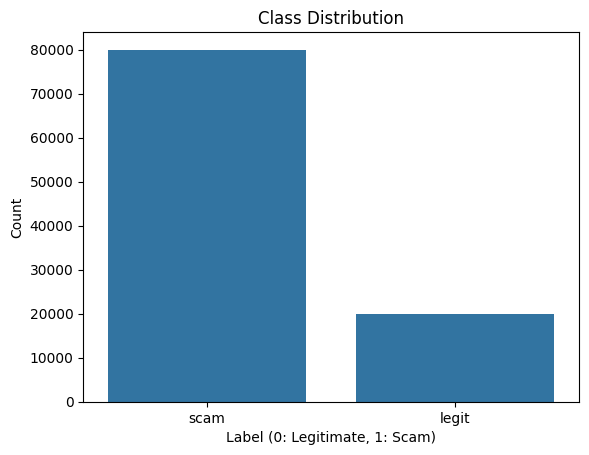

In [11]:
#  count the number of scam and legitimate links
class_distribution = datasets_df["label"].value_counts()

# plot the distribution
sns.barplot(x=class_distribution.index, y=class_distribution.values)
plt.title("Class Distribution")
plt.xlabel("Label (0: Legitimate, 1: Scam)")
plt.ylabel("Count")
plt.show()

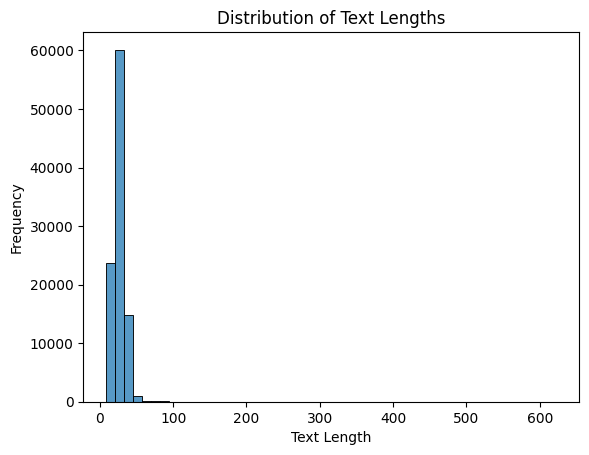

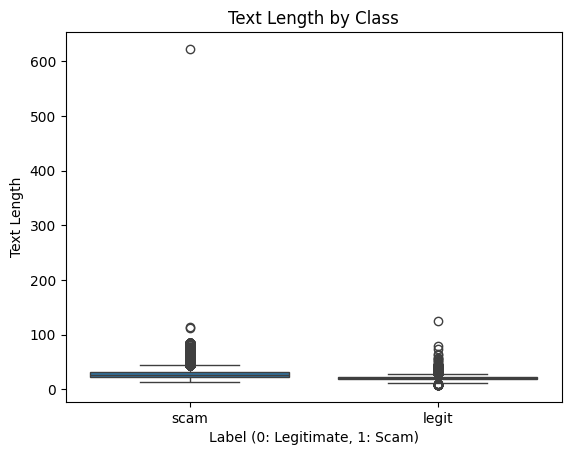

In [12]:
# add a column for text length
datasets_df["url_length"] = datasets_df["url"].apply(len)

# plot the distribution of text lengths
sns.histplot(datasets_df["url_length"], bins=50)
plt.title("Distribution of Text Lengths")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

# compare text lengths for scam vs. legitimate links
sns.boxplot(x="label", y="url_length", data=datasets_df)
plt.title("Text Length by Class")
plt.xlabel("Label (0: Legitimate, 1: Scam)")
plt.ylabel("Text Length")
plt.show()

Unique domains: 65170
Top TLDs: tld
com       34117
io        10692
xyz        5337
net        5153
app        4701
org        4336
dev        3922
top        1845
online     1564
site       1511
Name: count, dtype: int64


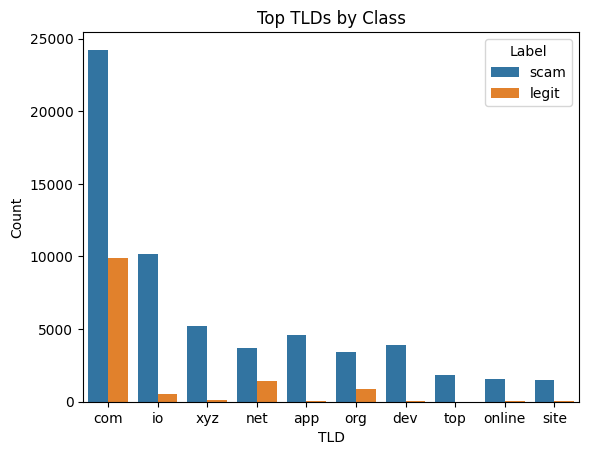

In [13]:
# extract domain and TLD
datasets_df["domain"] = datasets_df["url"].apply(lambda x: tldextract.extract(x).domain)
datasets_df["tld"] = datasets_df["url"].apply(lambda x: tldextract.extract(x).suffix)

# count unique domains and TLDs
print("Unique domains:", datasets_df["domain"].nunique())
print("Top TLDs:", datasets_df["tld"].value_counts().head(10))

# compare TLDs for scam vs. legitimate links
sns.countplot(x="tld", hue="label", data=datasets_df, order=datasets_df["tld"].value_counts().iloc[:10].index)
plt.title("Top TLDs by Class")
plt.xlabel("TLD")
plt.ylabel("Count")
plt.legend(title="Label", loc="upper right")
plt.show()

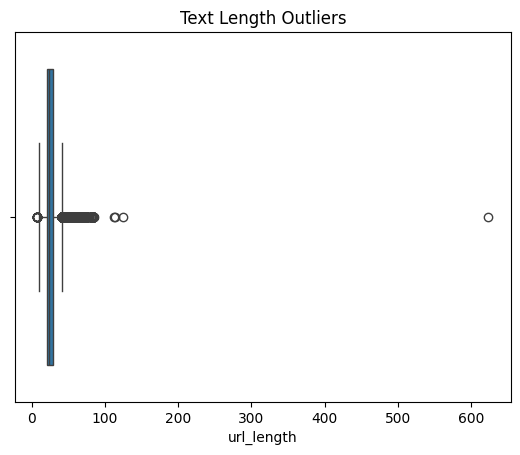

In [14]:
# boxplot for text length
sns.boxplot(x=datasets_df["url_length"])
plt.title("Text Length Outliers")
plt.show()

## preprocessing

In [15]:
# function to process url
def procees_url(url):
    """Extracts features from a URL."""

    TECHNICAL_WORDS = {"www", "http", "https"}

    SCAM_KEYWORDS = [
    "free", "giveaway", "bonus", "earn", "profit", "double", "investment",
    "claim", "win", "lottery", "rich", "money", "wallet", "support",
    "verification", "login", "secure", "account", "recovery"
]

    # Convert to lowercase
    url = url.lower()

    # Extract domain, subdomain, and suffix
    extracted = tldextract.extract(url)
    # domain = extracted.domain
    subdomain = extracted.subdomain
    tld = extracted.suffix

    # tokenisation (split URL into words based on delimiters)
    tokens = re.split(r"[-._~:/?#\[\]@!$&'()*+,;=]+", url)
    # remove only technical words
    filtered_tokens = [t for t in tokens if t and t not in TECHNICAL_WORDS and t != tld]
    filtered_tokens = " ".join(filtered_tokens)

    # Count URL length and number of special characters
    url_length = len(url)
    special_char_count = len(re.findall(r'[.-_/]', url))

    # Common suspicious keywords
    keyword_count = sum(1 for token in tokens if token in SCAM_KEYWORDS)

    return {
        'subdomain': subdomain,
        'special_char_count': special_char_count,
        'keyword_count': keyword_count,
        "tokenized_tokens": filtered_tokens
    }

def detect_typosquatting(url, legitimate_domains, threshold=2):
    # extract domain from URL
    parsed_url = urlparse(url)
    domain = parsed_url.netloc

    # check similarity with legitimate domains
    min_distance = float("inf")
    for legit_domain in legitimate_domains:
        dist = levenshtein_distance(domain, legit_domain)
        if dist < min_distance:
            min_distance = dist

    # flag as typosquatting if the minimum distance is below the threshold
    return int(min_distance <= threshold)

def get_domain_age(url):
    try:
        # fetch domain registration details
        domain_info = whois.whois(url)

        # extract creation date
        creation_date = domain_info.creation_date
        if isinstance(creation_date, list):
            creation_date = creation_date[0]

        # calculate domain age in days
        if creation_date:
            domain_age = (datetime.now() - creation_date).days
        else:
            domain_age = None
    except Exception as e:
        # handle errors (e.g., invalid domain or WHOIS lookup failure)
        domain_age = None

    # return -1 if domain age cannot be determined
    return domain_age if domain_age is not None else -1

In [16]:
# process the url
proceesed_df = pd.DataFrame([procees_url(url) for url in datasets_df["url"]])

In [17]:
# fetch legitimate domains
legitimate_domains = datasets_df[datasets_df["label_no"] == 0]

# detect typosquatting
proceesed_df["is_typosquatting"] = datasets_df["url"].apply(detect_typosquatting, legitimate_domains=legitimate_domains)

# fetch domain age
proceesed_df["domain_age"] = datasets_df["url"].apply(get_domain_age)

set(proceesed_df["domain_age"])

{-1}

In [18]:
datasets_df[['subdomain','special_char_count','keyword_count', 'tokenized_tokens']] = proceesed_df[['subdomain','special_char_count','keyword_count', 'tokenized_tokens']]
datasets_df

,url,label,label_no,url_length,domain,tld,subdomain,special_char_count,keyword_count,tokenized_tokens
0,https://arbitrum-claim.net,scam,1,26,arbitrum-claim,net,,4,1,arbitrum claim
1,https://allocate-dym.network,scam,1,28,allocate-dym,network,,4,0,allocate dym
2,https://rionegro.com.ar,legit,0,23,rionegro,com.ar,,5,0,rionegro com ar
3,https://net-layerzero.com,scam,1,25,net-layerzero,com,,4,0,net layerzero
4,https://leugss.top,scam,1,18,leugss,top,,4,0,leugss
...,...,...,...,...,...,...,...,...,...,...
99995,https://youversionapi.com,legit,0,25,youversionapi,com,,4,0,youversionapi
99996,https://saintssinnersnft.com,scam,1,28,saintssinnersnft,com,,4,0,saintssinnersnft
99997,https://convexfinence.com,scam,1,25,convexfinence,com,,4,0,convexfinence
99998,https://app.velar.co/swap,legit,0,25,velar,co,app,6,0,app velar swap


## feature engineering

In [19]:
label_map = {0: "legit", 1: "scam"}
label_map

{0: 'legit', 1: 'scam'}

#### tf-idf
- unigrams, bigrams, and trigrams

In [20]:
# TF-IDF vectorization
# vectorizer = TfidfVectorizer(max_features=5000)
vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
X_tfidf = vectorizer.fit_transform(datasets_df["tokenized_tokens"]).toarray()

#### nnlm

In [21]:
# using nnlm-50

# load NNLM embeddings (50-dimensional)
embed_50 = hub.load("https://tfhub.dev/google/nnlm-en-dim50/2")

# fetch embeddings of urls
X_embeddings_50 = embed_50(datasets_df["tokenized_tokens"].tolist()).numpy()

X_embeddings_50

INFO:absl:Using /var/folders/zn/6wprcrg968v6zv05_s_8vf180000gn/T/tfhub_modules to cache modules.
INFO:absl:Downloading TF-Hub Module 'https://tfhub.dev/google/nnlm-en-dim50/2'.
INFO:absl:Downloading https://tfhub.dev/google/nnlm-en-dim50/2: 108.00MB
INFO:absl:Downloaded https://tfhub.dev/google/nnlm-en-dim50/2, Total size: 191.83MB
INFO:absl:Downloaded TF-Hub Module 'https://tfhub.dev/google/nnlm-en-dim50/2'.
2025-03-21 19:25:25.780257: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'sentences' with dtype string and shape [?]
	 [[{{node sentences}}]]


array([[ 0.03077845, -0.26711562,  0.01830282, ...,  0.2072107 ,
         0.02002396,  0.11362913],
       [ 0.09021033, -0.11310953, -0.01836494, ..., -0.04607791,
         0.32672518,  0.29600132],
       [ 0.25377196, -0.34026453, -0.12066936, ...,  0.22596207,
         0.09758832,  0.09508254],
       ...,
       [ 0.42437407,  0.17515412,  0.0380774 , ...,  0.06362747,
        -0.03616028,  0.16073953],
       [-0.02407272, -0.12908407,  0.06917293, ...,  0.07424267,
         0.23407026,  0.15360208],
       [ 0.20205095,  0.2557025 ,  0.00315733, ...,  0.2201928 ,
        -0.03696417, -0.01444183]], dtype=float32)

In [ ]:
# using nnlm-128

# load NNLM embeddings (128-dimensional)
embed_128 = hub.load("https://tfhub.dev/google/nnlm-en-dim50/2")

# fetch embeddings of urls
X_embeddings_128 = embed_128(datasets_df["tokenized_tokens"].tolist()).numpy()

X_embeddings_128

2025-03-21 19:25:27.305220: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'sentences' with dtype string and shape [?]
	 [[{{node sentences}}]]


array([[ 0.03077845, -0.26711562,  0.01830282, ...,  0.2072107 ,
         0.02002396,  0.11362913],
       [ 0.09021033, -0.11310953, -0.01836494, ..., -0.04607791,
         0.32672518,  0.29600132],
       [ 0.25377196, -0.34026453, -0.12066936, ...,  0.22596207,
         0.09758832,  0.09508254],
       ...,
       [ 0.42437407,  0.17515412,  0.0380774 , ...,  0.06362747,
        -0.03616028,  0.16073953],
       [-0.02407272, -0.12908407,  0.06917293, ...,  0.07424267,
         0.23407026,  0.15360208],
       [ 0.20205095,  0.2557025 ,  0.00315733, ...,  0.2201928 ,
        -0.03696417, -0.01444183]], dtype=float32)

#### pre-trained word2Vec

In [40]:
# Train a Word2Vec model
word2vec_model = Word2Vec(
    sentences=datasets_df["tokenized_tokens"],  # List of tokenized URLs
    vector_size=100,           # Dimensionality of the word vectors
    window=5,                  # Maximum distance between the current and predicted word
    min_count=1,               # Ignores words with frequency lower than this
    workers=4,                 # Number of CPU cores
    sg=1,                      # Use skip-gram (1) or CBOW (0)
    epochs=10                  # Number of iterations over the corpus
)

INFO:gensim.models.word2vec:collecting all words and their counts


INFO:gensim.models.word2vec:PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #10000, processed 136013 words, keeping 37 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #20000, processed 270806 words, keeping 37 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #30000, processed 407462 words, keeping 37 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #40000, processed 545715 words, keeping 37 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #50000, processed 681692 words, keeping 38 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #60000, processed 817791 words, keeping 38 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #70000, processed 952372 words, keeping 38 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #80000, processed 1087964 words, keeping 39 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #90000, processed 12243

In [33]:
def get_document_embedding(tokens, word2vec_model):
    embeddings = [word2vec_model.wv[word] for word in tokens if word in word2vec_model.wv]
    if embeddings:
        return np.mean(embeddings, axis=0)  # Average word embeddings
    else:
        return np.zeros(word2vec_model.vector_size)  # Return zero vector if no words are found

In [34]:
datasets_df["word2vec_embedding"] = datasets_df["tokenized_tokens"].apply(
    lambda x: get_document_embedding(x, word2vec_model)
)

# convert word2Vec embeddings to a numpy array
X_word2vec = np.array(datasets_df["word2vec_embedding"].tolist())

#### feature engineering II

In [35]:
# Combine with URL-specific features
X_combined = np.hstack((X_word2vec, datasets_df[["url_length", "special_char_count", "keyword_count"]].values))

In [36]:
# split the data
X_train, X_test, y_train, y_test = train_test_split(X_combined, datasets_df["label"], test_size=0.2, random_state=42)

print("number of tweets in training dataset: ", X_train.shape[0])
print("number of tweets in testing dataset: ", X_test.shape[0])

number of tweets in training dataset:  80000
number of tweets in testing dataset:  20000


## modelling

In [51]:
# Convert tokens to sequences of indices
token_to_index = {token: i for i, token in enumerate(set(token for tokens in datasets_df["tokenized_tokens"] for token in tokens))}

X_seq = datasets_df["tokenized_tokens"].apply(lambda x: [token_to_index[token] for token in x])

# Pad sequences
max_len = 10  # Set maximum sequence length

X_padded = pad_sequences(X_seq, maxlen=max_len, padding="post", truncating="post")

#### logistics regression

In [37]:
def get_confusion_metric(model, X_train, y_train, X_test, y_test):
    # train the model on training data
    model.fit(X_train, y_train)

    # evaluate the model
    y_pred = model.predict(X_test)

    # calculate the performance metrics
    accuracy = accuracy_score(y_test, y_pred)

    confusion = confusion_matrix(y_test, y_pred)


    return accuracy, confusion

def train_model(model_name, model):
    accuracy, confusion = get_confusion_metric(model, X_train, y_train, X_test, y_test)
    print("Model Name:", model_name)
    print("Accuracy: ", accuracy)
    print("Confusion Matrix: ", confusion)
    disp = ConfusionMatrixDisplay(confusion, display_labels = label_map.keys())
    disp.plot()
    plt.show()

In [43]:
# logistic regression
lr_model = LogisticRegression(class_weight="balanced", random_state=42)

/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model Name: Logistic Regression
Accuracy:  0.7267
Confusion Matrix:  [[ 3182   761]
 [ 4705 11352]]


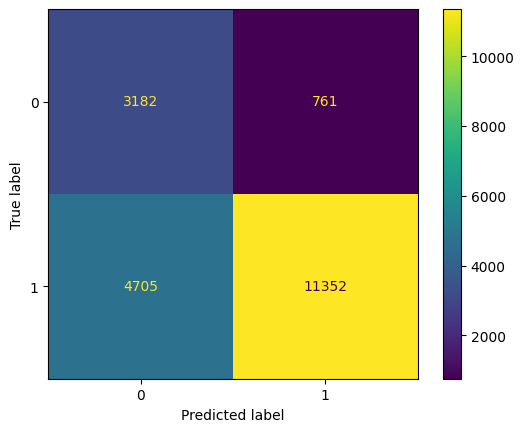

In [39]:
# using logisitics regression
train_model("Logistic Regression", lr_model)

#### LSTM

In [50]:
# Build an LSTM model
lstm_model = Sequential([
    Masking(mask_value=0, input_shape=(max_len,)),  # Mask padded values
    Embedding(input_dim=len(token_to_index) + 1, output_dim=50, input_length=max_len),
    LSTM(64),
    Dense(1, activation="sigmoid")
])

# compile the model
lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# train the model
lstm_model.fit(X_padded, datasets_df["label"], epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10


2025-03-21 19:51:41.413087: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2025-03-21 19:51:41.417656: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2025-03-21 19:51:41.424028: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

UnimplementedError: Graph execution error:

Detected at node 'binary_crossentropy/Cast' defined at (most recent call last):
    File "/Applications/Xcode.app/Contents/Developer/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 197, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/Applications/Xcode.app/Contents/Developer/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/runpy.py", line 87, in _run_code
      exec(code, run_globals)
    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance
      app.start()
    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/ipykernel/kernelapp.py", line 739, in start
      self.io_loop.start()
    File "/Users/sooreoluwa/Library/Pyth

#### CNN

In [53]:
# Convert tokens to sequences of indices
token_to_index = {token: i for i, token in enumerate(set(token for tokens in datasets_df["tokenized_tokens"] for token in tokens))}

# Pad sequences
max_len = 10  # Set maximum sequence length

cnn_model = Sequential([
    Embedding(input_dim=len(token_to_index) + 1, output_dim=50, input_length=max_len),
    Conv1D(128, 5, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(1, activation="sigmoid")
])

cnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

cnn_model.summary()

cnn_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)


Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_5 (Embedding)     (None, 10, 50)            2000      
                                                                 
 conv1d_3 (Conv1D)           (None, 6, 128)            32128     
                                                                 
 global_max_pooling1d_3 (Glo  (None, 128)              0         
 balMaxPooling1D)                                                
                                                                 
 dense_5 (Dense)             (None, 1)                 129       
                                                                 
Total params: 34,257
Trainable params: 34,257
Non-trainable params: 0
_________________________________________________________________
Epoch 1/10


ValueError: in user code:

    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/keras/engine/training.py", line 1284, in train_function  *
        return step_function(self, iterator)
    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/keras/engine/training.py", line 1268, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/keras/engine/training.py", line 1249, in run_step  **
        outputs = model.train_step(data)
    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/keras/engine/training.py", line 1050, in train_step
        y_pred = self(x, training=True)
    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/keras/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/keras/

In [54]:
# evaluate the model
loss, accuracy = cnn_model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

ValueError: in user code:

    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/keras/engine/training.py", line 1852, in test_function  *
        return step_function(self, iterator)
    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/keras/engine/training.py", line 1836, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/keras/engine/training.py", line 1824, in run_step  **
        outputs = model.test_step(data)
    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/keras/engine/training.py", line 1788, in test_step
        y_pred = self(x, training=False)
    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/keras/utils/traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "/Users/sooreoluwa/Library/Python/3.9/lib/python/site-packages/keras/en